### Import librairies

In [59]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.special import ndtr, ndtri

# Find the project root so this notebook also works when launched from a subfolder.
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "python_module" / "pricing_model.py").is_file():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not find python_module/pricing_model.py from the notebook directory")

sns.set_theme()
# Show large numbers as 1_000_000; small ones (deltas, prices) keep 4 significant digits
pd.set_option("display.float_format", lambda x: f"{x:_.0f}" if abs(x) >= 1_000 else f"{x:.4g}")

from python_module.pricing_model import BSMModel, SABRModel

### Custom functions

In [60]:
# Functions used across the notebook. They read notebook variables defined in the sections below,
# so they can be defined here and called once those sections have run.

# --- Monte Carlo simulation ---
def simulate_sabr_paths(F0, T, alpha, beta, rho, nu, n_steps, n_paths, seed=None):
    """Simulate SABR forward and vol paths: dF = sigma * F^beta * dW, dsigma = nu * sigma * dZ, d<W, Z> = rho dt.

    The vol is simulated exactly (lognormal) and the forward with a log-Euler step, which keeps F > 0.
    Returns (F_paths, sigma_paths) as DataFrames indexed by time (years), one column per path.
    """
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    dW = rng.standard_normal((n_steps, n_paths)) * np.sqrt(dt)
    dZ = rho * dW + np.sqrt(1 - rho ** 2) * rng.standard_normal((n_steps, n_paths)) * np.sqrt(dt)

    F = np.empty((n_steps + 1, n_paths))
    sigma = np.empty((n_steps + 1, n_paths))
    F[0], sigma[0] = F0, alpha
    for i in range(n_steps):
        local_vol = sigma[i] * F[i] ** (beta - 1)       # lognormal vol of F over the step
        F[i + 1] = F[i] * np.exp(local_vol * dW[i] - 0.5 * local_vol ** 2 * dt)
        sigma[i + 1] = sigma[i] * np.exp(nu * dZ[i] - 0.5 * nu ** 2 * dt)

    times = np.linspace(0, T, n_steps + 1)
    return pd.DataFrame(F, index=times), pd.DataFrame(sigma, index=times)


# --- Pricing (vectorised Hagan SABR vol + Black-76) ---
def sabr_vol(F, K, T, alpha, beta, rho, nu):
    """Hagan et al. (2002) lognormal implied vol, vectorised over K."""
    K = np.asarray(K, dtype=float)
    fk_pow = (F * K) ** (0.5 * (1 - beta))
    log_fk = np.log(F / K)
    z = nu / alpha * fk_pow * log_fk
    x = np.log((np.sqrt(1 - 2 * rho * z + z ** 2) + z - rho) / (1 - rho))
    small = np.abs(z) < 1e-7
    z_over_x = np.where(small, 1.0, z / np.where(small, 1.0, x))
    denom = fk_pow * (1 + (1 - beta) ** 2 / 24 * log_fk ** 2 + (1 - beta) ** 4 / 1920 * log_fk ** 4)
    corr = 1 + ((1 - beta) ** 2 / 24 * alpha ** 2 / fk_pow ** 2
                + 0.25 * rho * beta * nu * alpha / fk_pow
                + (2 - 3 * rho ** 2) / 24 * nu ** 2) * T
    return alpha / denom * z_over_x * corr


def black_price(F, K, T, vol, is_call, r=0.0):
    """Discounted Black-76 price, vectorised over K. T <= 0 returns intrinsic."""
    K = np.asarray(K, dtype=float)
    if T <= 0:
        return np.where(is_call, np.maximum(F - K, 0.0), np.maximum(K - F, 0.0))
    sd = vol * np.sqrt(T)
    d1 = np.log(F / K) / sd + 0.5 * sd
    call = F * ndtr(d1) - K * ndtr(d1 - sd)
    return np.exp(-r * T) * np.where(is_call, call, call - (F - K))


def portfolio_pv(weights, F, T_left, alpha, beta, rho, nu):
    """PV of a portfolio of options (weights indexed by (option_type, strike)) under SABR."""
    strikes = weights.index.get_level_values("strike").to_numpy()
    is_call = weights.index.get_level_values("option_type").to_numpy() == "call"
    vol = sabr_vol(F, strikes, max(T_left, 1e-12), alpha, beta, rho, nu)
    return weights.to_numpy() @ black_price(F, strikes, T_left, vol, is_call, r)



def bartlett_bumped_pvs(weights, F, T_left, alpha, beta, rho, nu, rel_bump=1e-4):
    """PVs at F - h, F, F + h, with alpha moving along its expected shift dalpha = rho * nu / F^beta * dF (Bartlett 2006)."""
    h = F * rel_bump
    d_alpha = rho * nu / F ** beta * h
    down = portfolio_pv(weights, F - h, T_left, alpha - d_alpha, beta, rho, nu)
    base = portfolio_pv(weights, F, T_left, alpha, beta, rho, nu)
    up = portfolio_pv(weights, F + h, T_left, alpha + d_alpha, beta, rho, nu)
    return down, base, up, h


def bartlett_delta(weights, F, T_left, alpha, beta, rho, nu):
    """SABR delta including the forward / vol correlation (Bartlett 2006): dPV/dF + dPV/dalpha * rho * nu / F^beta."""
    down, _, up, h = bartlett_bumped_pvs(weights, F, T_left, alpha, beta, rho, nu)
    return (up - down) / (2 * h)


def bartlett_gamma_cash(weights, F, T_left, alpha, beta, rho, nu):
    """Gamma cash (Gamma * F^2 / 100, P&L per 1% move squared) with Gamma taken along the Bartlett direction."""
    down, base, up, h = bartlett_bumped_pvs(weights, F, T_left, alpha, beta, rho, nu)
    return (up - 2 * base + down) / h ** 2 * F ** 2 / 100


def headline_risks(weights, F, T_left, alpha, bump=0.10):
    """Headline risks of a portfolio under the pricing SABR parameters (alpha = current vol):
    bartlett_delta, gamma_cash, and PV(param * (1 + bump)) - PV(param) for alpha, rho and nu."""
    params = {"alpha": alpha, "beta": pricing_beta, "rho": pricing_rho, "nu": pricing_nu}
    base = portfolio_pv(weights, F, T_left, **params)
    return {
        "bartlett_delta": bartlett_delta(weights, F, T_left, **params),
        "gamma_cash": bartlett_gamma_cash(weights, F, T_left, **params),
        **{name: portfolio_pv(weights, F, T_left, **{**params, name: params[name] * (1 + bump)}) - base
           for name in ("alpha", "rho", "nu")},
    }

# --- Benchmark portfolio ---
# Target payoffs replicated by the strip, as a function of terminal spot S and the strip centre S_star.
BENCHMARK_PAYOFFS = {
    "variance_swap": lambda S, S_star: 2 / T * ((S - S_star) / S_star - np.log(S / S_star)),
    "gamma_swap": lambda S, S_star: 2 / T * (S / S_star * np.log(S / S_star) - S / S_star + 1),
}


def delta_to_strike(delta, F, alpha, T_left):
    """Strike of a Black-76 delta (negative: put delta, positive: call delta) at the SABR ATM vol."""
    atm_sd = sabr_vol(F, F, T_left, alpha, pricing_beta, pricing_rho, pricing_nu) * np.sqrt(T_left)
    call_delta = np.where(np.asarray(delta) < 0, 1 + np.asarray(delta) / np.exp(-r * T_left), np.asarray(delta) / np.exp(-r * T_left))
    return F * np.exp(-ndtri(call_delta) * atm_sd + 0.5 * atm_sd ** 2)


def delta_strike_bounds(min_delta_strike, max_delta_strike, F, alpha, T_left):
    """Strikes of the min (put) and max (call) delta."""
    return delta_to_strike(min_delta_strike, F, alpha, T_left), delta_to_strike(max_delta_strike, F, alpha, T_left)


def grid_strikes(K_lower, K_upper, K_ref, dK):
    """Nodes of the fixed strike grid K_ref + k * dK lying inside [K_lower, K_upper]."""
    k = np.arange(np.ceil((K_lower - K_ref) / dK), np.floor((K_upper - K_ref) / dK) + 1)
    return np.round(K_ref + k * dK, 10)


def otm_index(strikes, F):
    """(option_type, strike) index: puts below the grid node closest to F, calls from it upwards."""
    S_star = strikes[np.argmin(np.abs(strikes - F))]
    return pd.MultiIndex.from_arrays(
        [np.where(strikes < S_star, "put", "call"), strikes], names=["option_type", "strike"]
    )


def strip_weights(portfolio_type, strikes, F):
    """Option strip replicating the benchmark payoff on an equally spaced strike grid.

    Weights are the kinks of the piecewise-linear interpolant of the payoff on the strikes, with one
    ghost node on each side so the boundary strikes carry weight. The payoff is centred on the node closest to F.
    """
    dK = strikes[1] - strikes[0]
    S_star = strikes[np.argmin(np.abs(strikes - F))]
    nodes = np.concatenate([[strikes[0] - dK], strikes, [strikes[-1] + dK]])
    slopes = np.diff(BENCHMARK_PAYOFFS[portfolio_type](nodes, S_star)) / np.diff(nodes)
    return pd.Series(np.diff(slopes), index=otm_index(strikes, F))


def track_portfolio(forward_ts, sigma_ts, rebalancing_frequency, new_weights, universe_update=None, bump=0.10):
    """Hold an option portfolio along one path, delta hedged every step with the forward.

    new_weights(t, F, alpha, T_left, current) -> weights Series indexed by (option_type, strike), called at t0 and every
    rebalancing_frequency steps (None: t0 only); current is the portfolio held so far (None at t0). universe_update(F, alpha, T_left) -> index of strikes to add to the
    universe at each step (listed with 0 weight when not held).
    Returns:
        weights: (option_type, strike) x time, weight held from each date to the next
                 (0 when in the universe but not held, NaN before the strike joins the universe)
        headline_risk: time x (bartlett_delta, gamma_cash, alpha, rho, nu) of the held portfolio (see headline_risks)
        pnl: time x (option_pnl, delta_hedge_pnl, total_pnl), P&L over the step ending at each date of the portfolio
             held from the previous date: option_pnl = PV change of the options, delta_hedge_pnl = -bartlett_delta *
             dF (forward hedge rebalanced every step), total_pnl = option_pnl + delta_hedge_pnl (0 at t0).
             Rebalancing trades at the pricing PV, so it adds no P&L.
    """
    universe = pd.MultiIndex.from_arrays([[], []], names=["option_type", "strike"])
    holdings, risks, pnls = {}, {}, {}
    current = None
    pricing_params = {"beta": pricing_beta, "rho": pricing_rho, "nu": pricing_nu}
    for i, t in enumerate(forward_ts.index):
        F, alpha, T_left = forward_ts[t], sigma_ts[t], T - t
        if current is None:
            pnls[t] = {"option_pnl": 0.0, "delta_hedge_pnl": 0.0}
        else:
            pnls[t] = {
                "option_pnl": portfolio_pv(current, F, T_left, alpha, **pricing_params) - held_pv,
                "delta_hedge_pnl": -held_delta * (F - held_F),
            }
        if T_left > 1e-12:
            if universe_update is not None:
                universe = universe.union(universe_update(F, alpha, T_left))
            if current is None or (rebalancing_frequency is not None and i % rebalancing_frequency == 0):
                current = new_weights(t, F, alpha, T_left, current)
        current = current.reindex(universe.union(current.index), fill_value=0.0)
        holdings[t] = current
        risks[t] = headline_risks(current, F, T_left, alpha, bump)
        held_pv, held_delta, held_F = portfolio_pv(current, F, T_left, alpha, **pricing_params), risks[t]["bartlett_delta"], F

    weights = pd.concat(holdings, axis=1).sort_index()
    headline_risk = pd.DataFrame.from_dict(risks, orient="index")
    pnl = pd.DataFrame.from_dict(pnls, orient="index")
    pnl["total_pnl"] = pnl["option_pnl"] + pnl["delta_hedge_pnl"]
    return weights, headline_risk, pnl


def benchmark_portfolio_creation(portfolio_type, min_delta_strike, max_delta_strike, n_options, forward_ts, sigma_ts,
                                 rebalancing_frequency, sizing=None, bump=0.10):
    """Benchmark option strip along one path, delta hedged with the forward (see track_portfolio for the outputs).

    The option universe lives on a fixed strike grid (n_options nodes between the delta bounds at t0). At each step
    the grid nodes inside the current delta bounds that are not yet in the universe are added (with 0 weight unless
    re-struck). Every rebalancing_frequency steps the strip is re-struck on the current in-range nodes around the
    current forward; with rebalancing_frequency=None the initial weights are held to expiry.
    sizing: {risk: quantity}, e.g. {"gamma_cash": 50_000_000}. Each new strip (t0 and every re-strike) is scaled so
    that this headline risk equals quantity when it is struck. None keeps the unit replication weights.
    Pricing uses the pricing SABR parameters with alpha set to the path's current vol sigma_ts.
    """
    if sizing is not None and len(sizing) != 1:
        raise ValueError(f"sizing must have exactly one {{risk: quantity}} entry, got {sizing}")

    K_lower, K_upper = delta_strike_bounds(min_delta_strike, max_delta_strike, forward_ts.iloc[0], sigma_ts.iloc[0], T)
    K_ref, dK = K_lower, (K_upper - K_lower) / (n_options - 1)

    def in_range_strikes(F, alpha, T_left):
        return grid_strikes(*delta_strike_bounds(min_delta_strike, max_delta_strike, F, alpha, T_left), K_ref, dK)

    def new_weights(t, F, alpha, T_left, current):
        weights = strip_weights(portfolio_type, in_range_strikes(F, alpha, T_left), F)
        if sizing is not None:
            (risk, quantity), = sizing.items()
            weights *= quantity / headline_risks(weights, F, T_left, alpha, bump)[risk]
        return weights

    def universe_update(F, alpha, T_left):
        return otm_index(in_range_strikes(F, alpha, T_left), F)

    return track_portfolio(forward_ts, sigma_ts, rebalancing_frequency, new_weights, universe_update, bump)


# --- Replication portfolio ---
def replication_portfolio_creation(min_delta_strike, max_delta_strike, forward_ts, sigma_ts, rebalancing_frequency,
                                   benchmark_risk, target_deltas, reset=True, bump=0.10):
    """Few-option portfolio matching the benchmark headline risks, delta hedged with the forward.

    Options are struck at the target deltas (negative: put delta, positive: call delta), which must lie inside the
    [min_delta_strike, max_delta_strike] strike range: puts <= min_delta_strike, calls >= max_delta_strike.
    At t0 and every rebalancing_frequency steps (None: t0 only), options at the current target delta strikes are traded
    so that the non-delta headline risks (gamma_cash, alpha, rho, nu) of the whole portfolio equal benchmark_risk:
        A q = b - existing risk,  A[risk, option] = risk of one unit of each target delta option.
    reset=True: the existing portfolio is unwound (existing risk = 0) and replaced by q, so only the current target
    delta options are held (unwound options stay listed with 0 weight).
    reset=False: q is traded on top of the existing portfolio (existing options are kept, not unwound). The number of
    options held grows through time; when a target delta strike is already held, q is added to its quantity (which can
    change sign).
    bartlett_delta is not matched with options: it is hedged every step with the forward (delta_hedge_pnl).
    Returns weights, headline_risk, pnl as in track_portfolio.
    """
    risk_names = [name for name in benchmark_risk.columns if name != "bartlett_delta"]
    target_deltas = np.asarray(target_deltas, dtype=float)
    if len(target_deltas) != len(risk_names):
        raise ValueError(f"{len(risk_names)} target deltas needed to match {risk_names}, got {len(target_deltas)}")
    outside = target_deltas[((target_deltas < 0) & (target_deltas > min_delta_strike))
                            | ((target_deltas > 0) & (target_deltas < max_delta_strike)) | (target_deltas == 0)]
    if outside.size:
        raise ValueError(f"target deltas {outside} outside the [{min_delta_strike}, {max_delta_strike}] delta strike range")
    option_types = np.where(target_deltas < 0, "put", "call")

    def new_weights(t, F, alpha, T_left, current):
        index = pd.MultiIndex.from_arrays(
            [option_types, delta_to_strike(target_deltas, F, alpha, T_left)], names=["option_type", "strike"]
        )
        unit_risks = pd.DataFrame({
            key: headline_risks(pd.Series([1.0], index=index[[j]]), F, T_left, alpha, bump)
            for j, key in enumerate(index)
        }).loc[risk_names]
        target = benchmark_risk.loc[t, risk_names]
        if current is not None and not reset:
            target = target - pd.Series(headline_risks(current, F, T_left, alpha, bump))[risk_names]
        trades = pd.Series(np.linalg.solve(unit_risks.to_numpy(), target.to_numpy()), index=index)
        if current is None:
            return trades
        if reset:
            return trades.reindex(trades.index.union(current.index), fill_value=0.0)
        return current.add(trades, fill_value=0.0)

    return track_portfolio(forward_ts, sigma_ts, rebalancing_frequency, new_weights, bump=bump)


### Inputs

In [61]:
# Market parameters
F0 = 100.0                                  # forward (spot = forward, no carry)
T = 252 / 252                                # maturity (years)
r = 0.00                                    # risk-free rate

# SABR parameters (Hagan 2002, lognormal backbone)
pricing_alpha = 0.20                                # initial vol level (~ ATM lognormal vol when beta = 1)
pricing_beta = 1.0                                  # CEV exponent: 1 = lognormal, 0 = normal
pricing_rho = -0.90                                 # spot / vol correlation (equity skew)
pricing_nu = 0.80                                   # vol of vol

realized_alpha = 0.20                                # initial vol level (~ ATM lognormal vol when beta = 1)
realized_beta = 1.0                                  # CEV exponent: 1 = lognormal
realized_rho = -0.90                                 # spot / vol correlation (equity skew)
realized_nu = 0.80                                   # vol of vol

# Option universe parameters
min_delta_strike = -0.01
max_delta_strike = 0.01
n_options = 100

# Replication portfolio parameters
replication_n_options = 10
replication_min_delta_strike = -0.1
replication_max_delta_strike = 0.1
replication_target_deltas = [-0.15, -0.35, 0.35, 0.15]   # one option per non-delta benchmark risk (put < 0, call > 0)
replication_rebalancing_frequency = 1       # trade the target delta options on top of the existing ones every n steps (None: t0 only)

# Benchmark portfolio parameters
portfolio_type = "variance_swap"           # "variance_swap" or "gamma_swap"
rebalancing_frequency = None                   # re-strike the strip around the forward every n steps (None: hold initial weights)
sizing = {"gamma_cash": 50_000_000}        # {risk: quantity} hit by each new strip (None: unit weights)

# Monte Carlo parameters
n_paths = 1_000                            # MC paths
n_steps = max(1, round(T * 252))            # MC steps (daily hedging)
seed = 42                                   # random seed

### Montecarlo Simulation

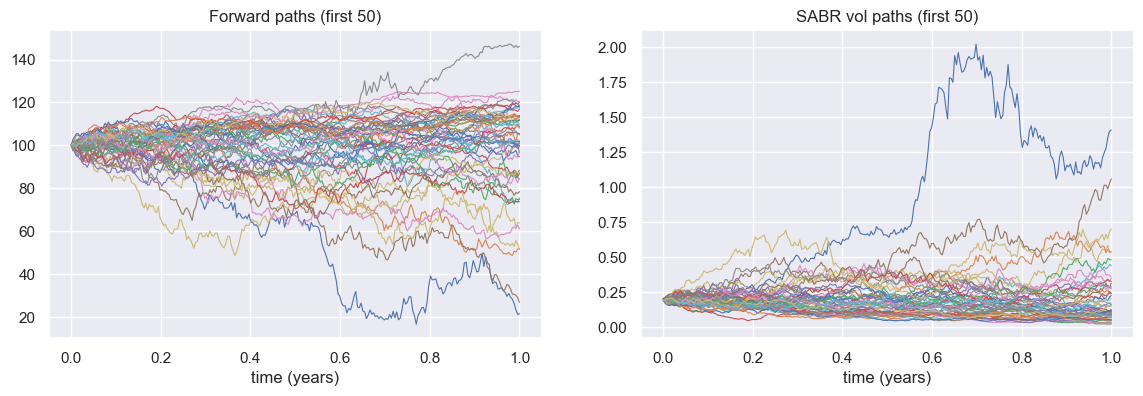

In [62]:
# Paths are simulated with the realized SABR parameters; options are priced with the pricing parameters.
F_paths, sigma_paths = simulate_sabr_paths(
    F0, T, realized_alpha, realized_beta, realized_rho, realized_nu, n_steps, n_paths, seed=seed
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
F_paths.iloc[:, :50].plot(ax=axes[0], legend=False, lw=0.8, title="Forward paths (first 50)")
sigma_paths.iloc[:, :50].plot(ax=axes[1], legend=False, lw=0.8, title="SABR vol paths (first 50)")
for ax in axes:
    ax.set_xlabel("time (years)")
plt.show()

### Benchmark Portfolio

0         0.003968  0.007937  0.0119    0.01587   \
option_type strike                                                     
call        100.2    531_222   531_222   531_222   531_222   531_222   
            101.2    521_376   521_376   521_376   521_376   521_376   
            102.1    511_802   511_802   511_802   511_802   511_802   
            103      502_489   502_489   502_489   502_489   502_489   
            104      493_427   493_427   493_427   493_427   493_427   
...                      ...       ...       ...       ...       ...   
put         95.51    584_900   584_900   584_900   584_900   584_900   
            96.46    573_532   573_532   573_532   573_532   573_532   
            97.4     562_493   562_493   562_493   562_493   562_493   
            98.34    551_770   551_770   551_770   551_770   551_770   
            99.28    541_350   541_350   541_350   541_350   541_350   

                    0.01984   0.02381   0.02778   0.03175   0.03571   ...  \
option_type strike                                                    ...   
call        100.2    531_222   531_222   531_222   531_222   531_222  ...   
            101.2    521_376   521_376   521_376   521_376   521_376  ...   
            102.1    511_802   511_802   511_802   511_802   511_802  ...   
            103      502_489   502_489   502_489   502_489   502_489  ...   
            104      493_427   493_427   493_427   493_427   493_427  ...   
...                      ...       ...       ...       ...       ...  ...   
put         95.51    584_900   584_900   584_900   584_900   584_900  ...   
            96.46    573_532   573_532   573_532   573_532   573_532  ...   
            97.4     562_493   562_493   562_493   562_493   562_493  ...   
            98.34    551_770   551_770   551_770   551_770   551_770  ...   
            99.28    541_350   541_350   541_350   541_350   541_350  ...   

                    0.9643    0.9683    0.9722    0.9762    0.9802    \
option_type strike                                                     
call        100.2    531_222   531_222   531_222   531_222   531_222   
            101.2    521_376   521_376   521_376   521_376   521_376   
            102.1    511_802   511_802   511_802   511_802   511_802   
            103      502_489   502_489   502_489   502_489   502_489   
            104      493_427   493_427   493_427   493_427   493_427   
...                      ...       ...       ...       ...       ...   
put         95.51    584_900   584_900   584_900   584_900   584_900   
            96.46    573_532   573_532   573_532   573_532   573_532   
            97.4     562_493   562_493   562_493   562_493   562_493   
            98.34    551_770   551_770   551_770   551_770   551_770   
            99.28    541_350   541_350   541_350   541_350   541_350   

                    0.9841    0.9881    0.9921    0.996     1         
option_type strike                                                    
call        100.2    531_222   531_222   531_222   531_222   531_222  
            101.2    521_376   521_376   521_376   521_376   521_376  
            102.1    511_802   511_802   511_802   511_802   511_802  
            103      502_489   502_489   502_489   502_489   502_489  
            104      493_427   493_427   493_427   493_427   493_427  
...                      ...       ...       ...       ...       ...  
put         95.51    584_900   584_900   584_900   584_900   584_900  
            96.46    573_532   573_532   573_532   573_532   573_532  
            97.4     562_493   562_493   562_493   562_493   562_493  
            98.34    551_770   551_770   551_770   551_770   551_770  
            99.28    541_350   541_350   541_350   541_350   541_350  

[100 rows x 253 columns]

,bartlett_delta,gamma_cash,alpha,rho,nu
0,-6_236_549,50_000_000,20_748_213,-3_694_633,1_754_822
0.003968,-5_482_869,54_327_724,18_085_283,-2_944_916,2_010_056
0.007937,-6_315_262,51_471_366,19_303_323,-3_303_004,1_795_196
0.0119,-7_186_246,48_573_639,20_526_553,-3_698_003,1_527_189
0.01587,-5_442_416,53_993_342,18_421_439,-2_978_796,1_990_245
...,...,...,...,...,...
0.9841,-2_072_498,57_122_400,408_886,-8.516,2_087
0.9881,-1_731_641,57_004_774,281_612,-3.242,1_077
0.9921,-1_304_011,56_887_441,176_621,-0.891,449.6
0.996,-2_639_859,56_770_571,111_741,-0.1452,142.1


,option_pnl,delta_hedge_pnl,total_pnl
0,0,0,0
0.003968,-17_764_389,6_898_078,-10_866_311
0.007937,8_156_014,-7_792_689,363_325
0.0119,9_701_058,-9_577_158,123_901
0.01587,-15_815_284,21_494_415,5_679_131
...,...,...,...
0.9881,-1_491_290,1_029_662,-461_628
0.9921,-1_439_529,1_133_609,-305_920
0.996,3_983_755,-2_921_461,1_062_294
1,1_278_637,-1_710_407,-431_770


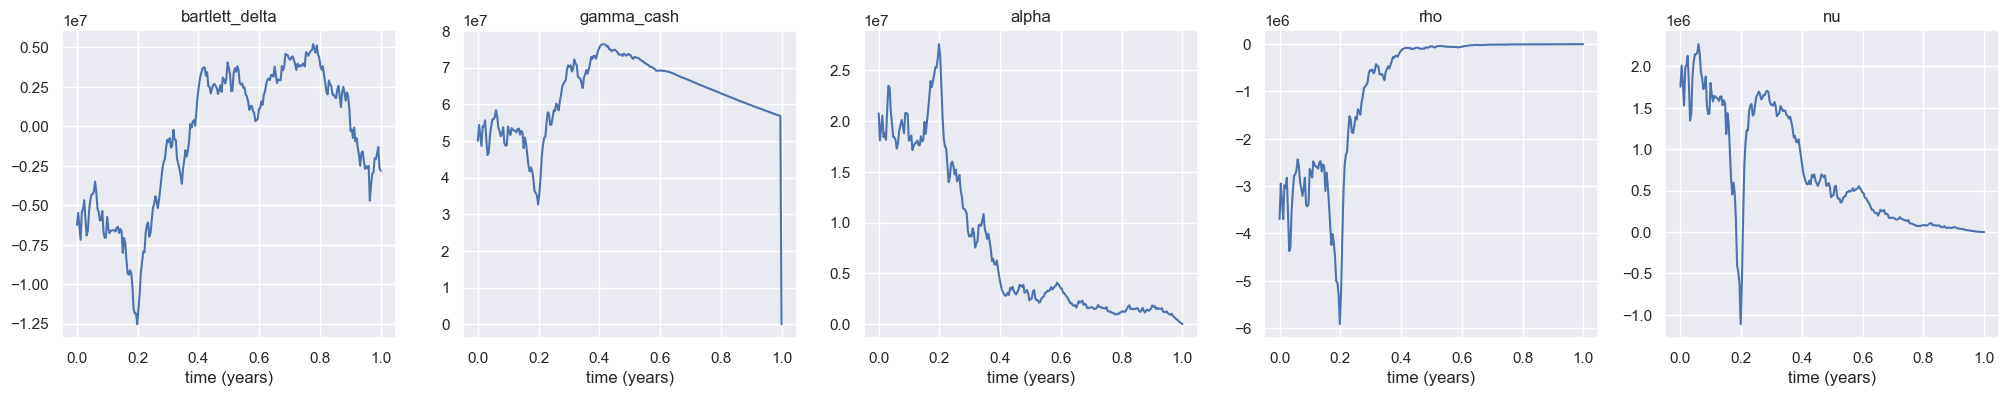

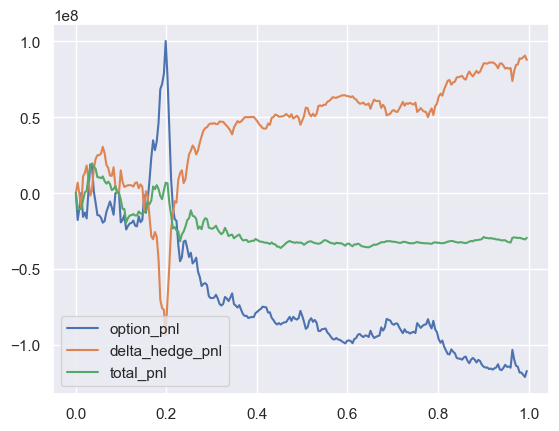

In [63]:
f_path_ts = F_paths[10]
sigma_path_ts = sigma_paths[10]
#f_path_ts.pct_change().std() * np.sqrt(252)

benchmark_weights, benchmark_risk, benchmark_pnl = benchmark_portfolio_creation(
    portfolio_type, min_delta_strike, max_delta_strike, n_options, f_path_ts, sigma_path_ts, rebalancing_frequency, sizing
)
display(benchmark_weights.replace(0, np.nan).dropna(how='all'))
display(benchmark_risk)
display(pd.concat([benchmark_pnl, benchmark_pnl.sum().to_frame("total").T]))

fig, axes = plt.subplots(1, len(benchmark_risk.columns), figsize=(25, 4))
for ax, name in zip(axes, benchmark_risk.columns):
    benchmark_risk[name].plot(ax=ax, title=name)
    ax.set_xlabel("time (years)")
plt.show()

benchmark_pnl.iloc[:-1].cumsum().plot();

### ATM Replication Portfolio

In [64]:
replication_weights.iloc[:, :10].dropna(how='all')

0          0.003968   0.007937   0.0119     0.01587   \
option_type strike                                                          
call        98.48         NaN        NaN        NaN        NaN        NaN   
            99.25         NaN        NaN        NaN        NaN        NaN   
            99.82         NaN        NaN        NaN        NaN        NaN   
            100.4         NaN 30_642_241          0          0          0   
            100.6         NaN        NaN        NaN        NaN        NaN   
            100.7         NaN        NaN 30_481_516          0          0   
            101           NaN        NaN        NaN        NaN        NaN   
            101.5         NaN        NaN        NaN        NaN 30_017_429   
            101.8  30_144_011          0          0          0          0   
            102           NaN        NaN        NaN 29_717_773          0   

                     0.01984    0.02381    0.02778    0.03175    0.03571   
option_type strike                                                         
call        98.48         NaN        NaN        NaN        NaN 29_950_341  
            99.25         NaN 30_247_075          0          0          0  
            99.82         NaN        NaN 29_821_821          0          0  
            100.4           0          0          0          0          0  
            100.6         NaN        NaN        NaN 29_596_669          0  
            100.7           0          0          0          0          0  
            101    29_718_882          0          0          0          0  
            101.5           0          0          0          0          0  
            101.8           0          0          0          0          0  
            102             0          0          0          0          0

0         0.003968  0.007937  0.0119    0.01587   \
option_type strike                                                     
call        90.42        NaN       NaN       NaN       NaN       NaN   
            91.5         NaN       NaN       NaN       NaN       NaN   
            91.55        NaN       NaN       NaN       NaN       NaN   
            91.96        NaN       NaN       NaN       NaN       NaN   
            92.01        NaN       NaN       NaN       NaN       NaN   
...                      ...       ...       ...       ...       ...   
            111.4        NaN       NaN       NaN       NaN       NaN   
            111.4        NaN       NaN       NaN       NaN       NaN   
            111.4        NaN       NaN       NaN       NaN       NaN   
            111.4        NaN       NaN       NaN       NaN       NaN   
            111.5        NaN       NaN       NaN       NaN       NaN   

                    0.01984   0.02381   0.02778   0.03175   0.03571   ...  \
option_type strike                                                    ...   
call        90.42        NaN       NaN       NaN       NaN       NaN  ...   
            91.5         NaN       NaN       NaN       NaN       NaN  ...   
            91.55        NaN       NaN       NaN       NaN       NaN  ...   
            91.96        NaN       NaN       NaN       NaN       NaN  ...   
            92.01        NaN       NaN       NaN       NaN       NaN  ...   
...                      ...       ...       ...       ...       ...  ...   
            111.4        NaN       NaN       NaN       NaN       NaN  ...   
            111.4        NaN       NaN       NaN       NaN       NaN  ...   
            111.4        NaN       NaN       NaN       NaN       NaN  ...   
            111.4        NaN       NaN       NaN       NaN       NaN  ...   
            111.5        NaN       NaN       NaN       NaN       NaN  ...   

                    0.9643    0.9683    0.9722    0.9762    0.9802    \
option_type strike                                                     
call        90.42        NaN       NaN       NaN       NaN       NaN   
            91.5         NaN       NaN       NaN       NaN       NaN   
            91.55        NaN       NaN       NaN       NaN       NaN   
            91.96        NaN       NaN       NaN       NaN       NaN   
            92.01        NaN       NaN       NaN       NaN       NaN   
...                      ...       ...       ...       ...       ...   
            111.4        NaN       NaN       NaN       NaN       NaN   
            111.4        NaN       NaN       NaN       NaN       NaN   
            111.4        NaN       NaN       NaN       NaN       NaN   
            111.4        NaN       NaN       NaN       NaN       NaN   
            111.5        NaN       NaN       NaN       NaN       NaN   

                    0.9841    0.9881    0.9921    0.996     1         
option_type strike                                                    
call        90.42        NaN       NaN       NaN       NaN       NaN  
            91.5         NaN       NaN       NaN       NaN       NaN  
            91.55        NaN       NaN       NaN       NaN       NaN  
            91.96        NaN       NaN       NaN       NaN       NaN  
            92.01        NaN       NaN       NaN       NaN       NaN  
...                      ...       ...       ...       ...       ...  
            111.4        NaN       NaN       NaN       NaN       NaN  
            111.4        NaN       NaN       NaN       NaN       NaN  
            111.4        NaN       NaN       NaN       NaN       NaN  
            111.4        NaN       NaN       NaN       NaN       NaN  
            111.5        NaN       NaN       NaN       NaN       NaN  

[252 rows x 253 columns]

,bartlett_delta,gamma_cash,alpha,rho,nu
0,11_218_372,50_000_000,21_989_228,-4_791_671,-2_149_895
0.003968,10_718_876,54_327_724,19_400_960,-4_058_224,-1_753_900
0.007937,10_964_650,51_471_366,20_524_082,-4_363_117,-1_926_279
0.0119,11_186_218,48_573_639,21_619_810,-4_674_257,-2_107_580
0.01587,10_797_371,53_993_342,19_736_300,-4_102_883,-1_785_790
...,...,...,...,...,...
0.9841,1_876_068,57_122_400,391_225,-1_310,-613.7
0.9881,1_553_256,57_004_774,269_127,-665.9,-306.8
0.9921,1_226_424,56_887_441,168_595,-275.2,-125.3
0.996,1_004_026,56_770_571,106_546,-90.65,-43.28


,option_pnl,delta_hedge_pnl,total_pnl
0,0,0,0
0.003968,171_187,-12_408_339,-12_237_152
0.007937,-14_804_210,15_234_518,430_308
0.0119,-16_454_753,16_628_002,173_250
0.01587,39_682_600,-33_458_529,6_224_071
...,...,...,...
0.9881,420_950,-932_071,-511_121
0.9921,674_275,-1_016_831,-342_555
0.996,-1_619_435,2_747_638,1_128_203
1,-1_056_396,650_525,-405_871


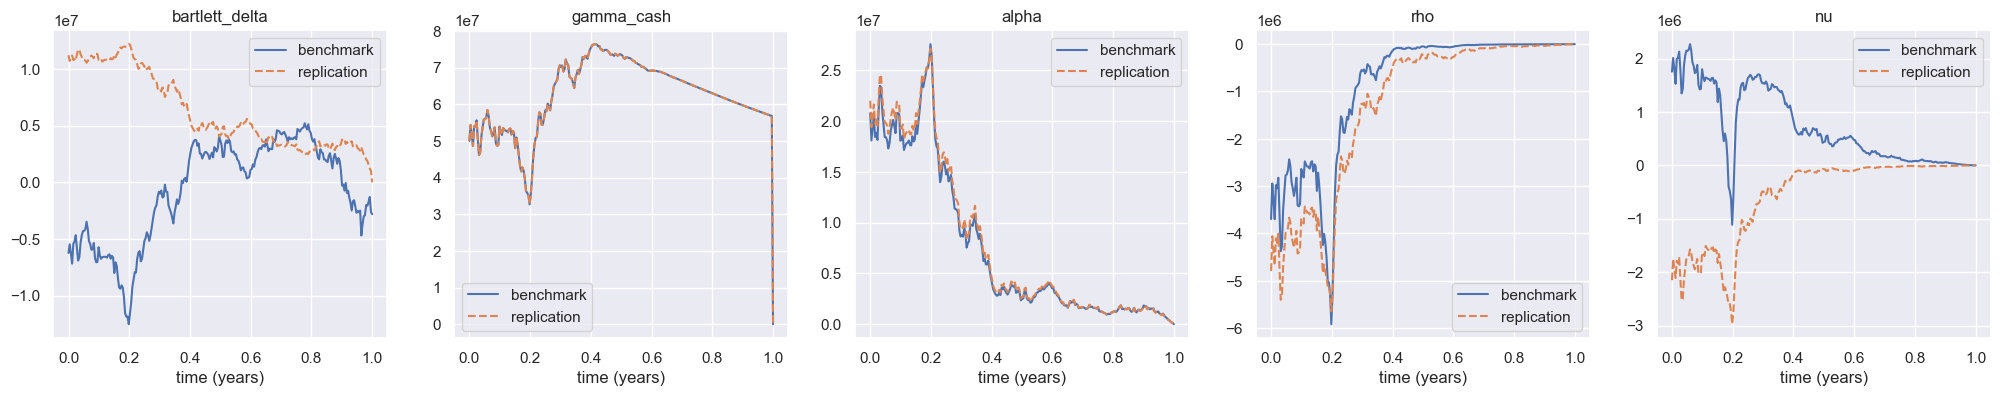

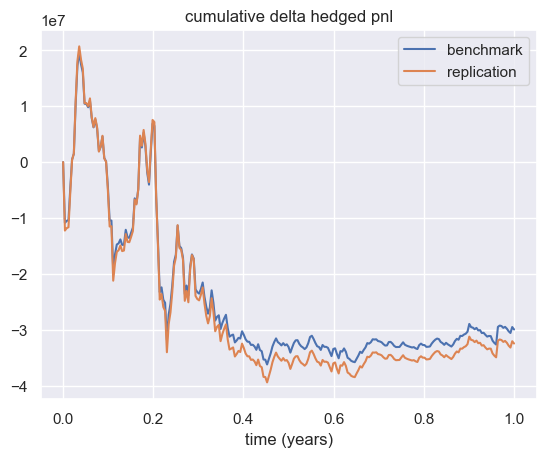

In [65]:
replication_weights, replication_risk, replication_pnl = replication_portfolio_creation(
    replication_min_delta_strike, replication_max_delta_strike, f_path_ts, sigma_path_ts,
    replication_rebalancing_frequency, benchmark_risk[['bartlett_delta', 'gamma_cash']], [0.5]
)
display(replication_weights.replace(0, np.nan).dropna(how='all'))
display(replication_risk)
display(pd.concat([replication_pnl, replication_pnl.sum().to_frame("total").T]))

fig, axes = plt.subplots(1, len(benchmark_risk.columns), figsize=(25, 4))
for ax, name in zip(axes, benchmark_risk.columns):
    benchmark_risk[name].plot(ax=ax, title=name, label="benchmark")
    replication_risk[name].plot(ax=ax, label="replication", ls="--")
    ax.set_xlabel("time (years)")
    ax.legend()
plt.show()

pd.DataFrame({
    "benchmark": benchmark_pnl["total_pnl"].cumsum(),
    "replication": replication_pnl["total_pnl"].cumsum(),
}).plot(title="cumulative delta hedged pnl", xlabel="time (years)")
plt.show()

### Strip Replication Portfolio

0         0.003968  0.007937  0.0119    0.01587   \
option_type strike                                                     
call        94.23        NaN       NaN       NaN       NaN       NaN   
            95.51        NaN       NaN       NaN       NaN       NaN   
            95.9         NaN       NaN       NaN       NaN       NaN   
            96.43        NaN       NaN       NaN       NaN       NaN   
            96.47        NaN       NaN       NaN       NaN       NaN   
...                      ...       ...       ...       ...       ...   
put         109          NaN       NaN       NaN       NaN       NaN   
            109.1        NaN       NaN       NaN       NaN       NaN   
            109.1        NaN       NaN       NaN       NaN       NaN   
            109.6        NaN       NaN       NaN       NaN       NaN   
            109.8        NaN       NaN       NaN       NaN       NaN   

                    0.01984   0.02381   0.02778   0.03175   0.03571   ...  \
option_type strike                                                    ...   
call        94.23        NaN       NaN       NaN       NaN       NaN  ...   
            95.51        NaN       NaN       NaN       NaN       NaN  ...   
            95.9         NaN       NaN       NaN       NaN       NaN  ...   
            96.43        NaN       NaN       NaN       NaN       NaN  ...   
            96.47        NaN       NaN       NaN       NaN       NaN  ...   
...                      ...       ...       ...       ...       ...  ...   
put         109          NaN       NaN       NaN       NaN       NaN  ...   
            109.1        NaN       NaN       NaN       NaN       NaN  ...   
            109.1        NaN       NaN       NaN       NaN       NaN  ...   
            109.6        NaN       NaN       NaN       NaN       NaN  ...   
            109.8        NaN       NaN       NaN       NaN       NaN  ...   

                      0.9643      0.9683      0.9722      0.9762    0.9802    \
option_type strike                                                             
call        94.23  -12_977_630         NaN         NaN         NaN       NaN   
            95.51          NaN -12_905_490         NaN         NaN       NaN   
            95.9           NaN         NaN         NaN         NaN       NaN   
            96.43          NaN         NaN -12_956_739         NaN       NaN   
            96.47          NaN         NaN         NaN -13_748_551       NaN   
...                        ...         ...         ...         ...       ...   
put         109            NaN         NaN         NaN         NaN       NaN   
            109.1          NaN         NaN         NaN         NaN       NaN   
            109.1          NaN         NaN         NaN         NaN       NaN   
            109.6          NaN         NaN         NaN         NaN       NaN   
            109.8          NaN         NaN         NaN         NaN       NaN   

                    0.9841    0.9881    0.9921      0.996       1         
option_type strike                                                        
call        94.23        NaN       NaN       NaN         NaN         NaN  
            95.51        NaN       NaN       NaN         NaN         NaN  
            95.9         NaN       NaN       NaN -17_662_234 -17_662_234  
            96.43        NaN       NaN       NaN         NaN         NaN  
            96.47        NaN       NaN       NaN         NaN         NaN  
...                      ...       ...       ...         ...         ...  
put         109          NaN       NaN       NaN         NaN         NaN  
            109.1        NaN       NaN       NaN         NaN         NaN  
            109.1        NaN       NaN       NaN         NaN         NaN  
            109.6        NaN       NaN       NaN         NaN         NaN  
            109.8        NaN       NaN       NaN         NaN         NaN  

[1008 rows x 253 columns]

,bartlett_delta,gamma_cash,alpha,rho,nu
0,-4_960_649,50_000_000,20_748_213,-3_694_633,1_754_822
0.003968,-3_980_619,54_327_724,18_085_283,-2_944_916,2_010_056
0.007937,-4_629_154,51_471_366,19_303_323,-3_303_004,1_795_196
0.0119,-5_233_816,48_573_639,20_526_553,-3_698_003,1_527_189
0.01587,-4_059_886,53_993_342,18_421_439,-2_978_796,1_990_245
...,...,...,...,...,...
0.9841,-8_340_076,57_122_400,408_886,-8.516,2_087
0.9881,-8_208_004,57_004_774,281_612,-3.242,1_077
0.9921,-8_145_786,56_887_441,176_621,-0.891,449.6
0.996,-9_540_858,56_770_571,111_741,-0.1452,142.1


,option_pnl,delta_hedge_pnl,total_pnl
0,0,0,0
0.003968,-16_346_468,5_486_840,-10_859_628
0.007937,6_020_375,-5_657_572,362_803
0.0119,7_143_613,-7_020_158,123_455
0.01587,-9_975_947,15_654_603,5_678_656
...,...,...,...
0.9881,-4_576_278,4_143_530,-432_748
0.9921,-5_626_470,5_373_324,-253_146
0.996,19_562_076,-18_249_539,1_312_537
1,2_268_688,-6_181_676,-3_912_988


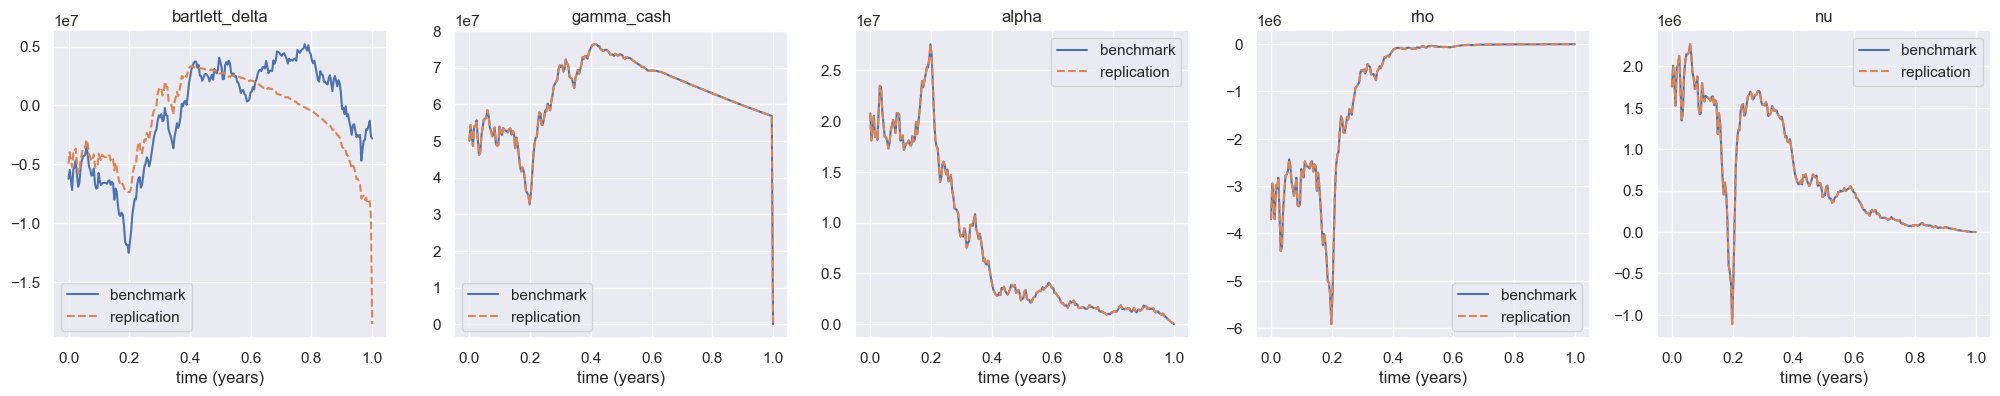

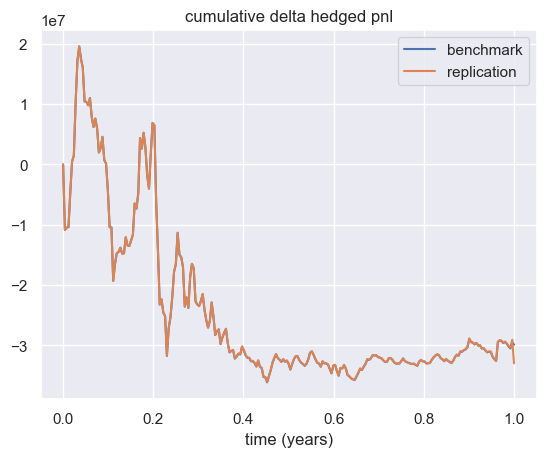

In [66]:
replication_weights, replication_risk, replication_pnl = replication_portfolio_creation(
    replication_min_delta_strike, replication_max_delta_strike, f_path_ts, sigma_path_ts,
    replication_rebalancing_frequency, benchmark_risk, replication_target_deltas
)
display(replication_weights.replace(0, np.nan).dropna(how='all'))
display(replication_risk)
display(pd.concat([replication_pnl, replication_pnl.sum().to_frame("total").T]))

fig, axes = plt.subplots(1, len(benchmark_risk.columns), figsize=(25, 4))
for ax, name in zip(axes, benchmark_risk.columns):
    benchmark_risk[name].plot(ax=ax, title=name, label="benchmark")
    replication_risk[name].plot(ax=ax, label="replication", ls="--")
    ax.set_xlabel("time (years)")
    ax.legend()
plt.show()

pd.DataFrame({
    "benchmark": benchmark_pnl["total_pnl"].cumsum(),
    "replication": replication_pnl["total_pnl"].cumsum(),
}).plot(title="cumulative delta hedged pnl", xlabel="time (years)")
plt.show()